# 10 - Determinación de la frontera temporal de utilidad

Este notebook evalúa el método seleccionado en el notebook 09 (CatBoost + CQR) sobre el rango completo de horizontes horarios $h \in \{1,\ldots,24\}$ a fin de determinar la frontera temporal de utilidad.

Por otro lado, también se efectúa la evaluación del método sobre el conjunto de prueba del año 2025, que cabe recordar no intervino en la selección del modelo. El objetivo es determinar hasta qué distancia temporal las predicciones conservan utilidad, atendiendo a los siguientes factores:

- Error puntual: MAE y RMSE
- Cobertura empírica
- Anchura media
- *Interval score*
- Fallos de cobertura
- Evolución de una puntuación específica de degradación por horizonte

Vemos que también se reutilizará la lógica de la puntuación de selección del notebook 09, pero adaptada al análisis de horizontes del método ganador.


## Configuración general

En primer lugar, se cargarán las salidas generadas por el notebook 09, es decir:

- Las métricas de CatBoost + CQR obtenidas en el conjunto de validación (2024) y prueba (2025) para los horizontes $1,...,24$
- Los intervalos calibrados del método CatBoost + CQR para generar las figuras correspondientes

In [1]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path
from typing import Any, Iterable, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook "
        "desde la raíz del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_INTERVALS_DIR = PROJECT_ROOT / "reports" / "intervals"

for directory in [REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR, REPORTS_INTERVALS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

ALPHA = 0.20
NOMINAL_COVERAGE = 1 - ALPHA
EXTENSION_HORIZONS = list(range(1, 25))
COMPACT_HORIZONS = [1, 2, 3, 4, 8, 11, 12, 18, 24]
VISUAL_HORIZONS = [1, 2, 3, 4, 24]

# Umbrales operativos para clasificar la utilidad. Se pueden modificar libremente si se
# desea adoptar una definición que sea más o menos exigente.
HIGH_COVERAGE_THRESHOLD = 0.75
MODERATE_COVERAGE_THRESHOLD = 0.70
HIGH_FRONTIER_SCORE_THRESHOLD = 0.25
MODERATE_FRONTIER_SCORE_THRESHOLD = 0.60

# Se replican los pesos del capítulo de selección del modelo ganador para la puntuación de degradación por horizonte.
WEIGHT_POINT = 0.40
WEIGHT_INTERVAL = 0.40
WEIGHT_COVERAGE = 0.20

SPANISH_MONTH_NAMES = {
    1: "enero",
    2: "febrero",
    3: "marzo",
    4: "abril",
    5: "mayo",
    6: "junio",
    7: "julio",
    8: "agosto",
    9: "septiembre",
    10: "octubre",
    11: "noviembre",
    12: "diciembre",
}

SAVED_TABLE_PATHS: list[Path] = []
SAVED_FIGURE_PATHS: list[Path] = []

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Tablas: {REPORTS_TABLES_DIR}")
print(f"Figuras: {REPORTS_FIGURES_DIR}")
print(f"Intervalos: {REPORTS_INTERVALS_DIR}")
print(f"Cobertura nominal: {NOMINAL_COVERAGE:.0%}")


Raíz del proyecto: c:\trabajo_github
Tablas: c:\trabajo_github\reports\tables
Figuras: c:\trabajo_github\reports\figures
Intervalos: c:\trabajo_github\reports\intervals
Cobertura nominal: 80%


## Funciones auxiliares

Se definen algunas funciones auxiliares para guardar las salidas, normalizar las métricas, calcular la puntuación de la degradación por horizonte y preparar las figuras.


In [3]:
def save_dataframe_csv(df: pd.DataFrame, path: Path, **kwargs: Any) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, **kwargs)
    SAVED_TABLE_PATHS.append(path)
    print(f"Tabla guardada: {path}")
    return path

def save_figure(fig: plt.Figure, path: Path, **kwargs: Any) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    save_kwargs = {"dpi": 300, "bbox_inches": "tight"}
    save_kwargs.update(kwargs)
    fig.savefig(path, **save_kwargs)
    SAVED_FIGURE_PATHS.append(path)
    print(f"Figura guardada: {path}")
    return path

def format_es(value: float, decimals: int = 3) -> str:
    if pd.isna(value):
        return "--"
    return f"{value:.{decimals}f}".replace(".", ",")

def spanish_axis_date(x: float, pos: int | None = None) -> str:
    dt = mdates.num2date(x)
    return f"{dt.day:02d} {SPANISH_MONTH_NAMES[dt.month]} {dt.year}"

def format_spanish_date(ts: pd.Timestamp | str) -> str:
    ts = pd.Timestamp(ts)
    return f"{ts.day:02d} {SPANISH_MONTH_NAMES[ts.month]} {ts.year}"

def minmax_normalize(series: pd.Series, eps: float = 1e-12) -> pd.Series:
    """Normaliza una serie a [0, 1]. Si todos los valores son iguales, devuelve cero."""
    series = series.astype(float)
    min_value = series.min()
    max_value = series.max()
    denom = max_value - min_value
    if pd.isna(denom) or abs(denom) < eps:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - min_value) / (denom + eps)

def first_existing_column(df: pd.DataFrame, candidates: Sequence[str], purpose: str) -> str:
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(
        f"No se encontró ninguna columna para {purpose}. "
        f"Candidatas: {list(candidates)}. Columnas disponibles: {list(df.columns)}"
    )

def contiguous_frontier(df: pd.DataFrame, ok_col: str, horizon_col: str = "horizon") -> int | None:
    """Devuelve el último horizonte contiguo, desde h=1, que cumple cierta condición."""
    ordered = df.sort_values(horizon_col)
    expected = 1
    last_ok = None
    for _, row in ordered.iterrows():
        horizon = int(row[horizon_col])
        if horizon != expected:
            break
        if bool(row[ok_col]):
            last_ok = horizon
            expected += 1
        else:
            break
    return last_ok

def normalize_interval_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    rename_map: dict[str, str] = {}
    candidates = {
        "y_true": ["y_true", "target", "y", "o3", "valor_observado"],
        "y_pred_central": ["y_pred_central", "y_pred", "prediction", "pred", "q50", "q_0_50", "q0_50"],
        "lower": ["lower", "lower_cqr", "y_lower", "q_low", "q10", "q_0_10", "q0_10"],
        "upper": ["upper", "upper_cqr", "y_upper", "q_high", "q90", "q_0_90", "q0_90"],
        "target_timestamp": ["target_timestamp", "timestamp", "fecha_objetivo"],
    }
    for canonical, cols in candidates.items():
        if canonical not in out.columns:
            for col in cols:
                if col in out.columns:
                    rename_map[col] = canonical
                    break
    if rename_map:
        out = out.rename(columns=rename_map)
    return out


## Carga de las métricas que se generaron en el notebook 09

Se cargan las métricas de CatBoost + CQR obtenidas sobre los conjuntos de validación y prueba para todos los horizontes entre 1 y 24 horas. La frontera se determinará a partir del conjunto de prueba; los resultados obtenidos a partir del conjunto de validación se conservarán para valorar el sobreajuste y la generalización fuera de muestra.


In [4]:
validation_metrics_path = REPORTS_TABLES_DIR / "winner_catboost_cqr_horizon_01_24_validation_metrics.csv"
test_metrics_path = REPORTS_TABLES_DIR / "winner_catboost_cqr_horizon_01_24_test_metrics.csv"
intervals_path = REPORTS_INTERVALS_DIR / "catboost_cqr_horizon_01_24_intervals.parquet"

if not validation_metrics_path.exists() or not test_metrics_path.exists():
    raise FileNotFoundError(
        "No se han encontrado las tablas de extensión 1-24 que se generaron en el notebook 09. "
        "Ejecuta primero el notebook 09_model_selection_and_horizon_extension_with_coverage.ipynb."
    )

validation_metrics_df = pd.read_csv(validation_metrics_path)
test_metrics_df = pd.read_csv(test_metrics_path)

metric_rename_candidates = {
    "empirical_coverage": ["empirical_coverage", "coverage", "cobertura"],
    "mean_width": ["mean_width", "width", "mean_interval_width", "anchura_media"],
    "mean_interval_score": ["mean_interval_score", "interval_score", "is", "interval_score_mean"],
    "mae": ["mae", "MAE"],
    "rmse": ["rmse", "RMSE"],
    "miss_lower_pct": ["miss_lower_pct", "below_lower_pct", "fallos_inf_pct"],
    "miss_upper_pct": ["miss_upper_pct", "above_upper_pct", "fallos_sup_pct"],
}

for df in [validation_metrics_df, test_metrics_df]:
    rename_map = {}
    for canonical, candidates in metric_rename_candidates.items():
        if canonical not in df.columns:
            for candidate in candidates:
                if candidate in df.columns:
                    rename_map[candidate] = canonical
                    break
    if rename_map:
        df.rename(columns=rename_map, inplace=True)

required_metric_cols = {"horizon", "mae", "rmse", "empirical_coverage", "mean_width", "mean_interval_score"}
for name, df in [("validación", validation_metrics_df), ("prueba", test_metrics_df)]:
    missing_cols = required_metric_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"Faltan columnas en las métricas de {name}: {sorted(missing_cols)}")
    missing_horizons = set(EXTENSION_HORIZONS) - set(df["horizon"].astype(int))
    if missing_horizons:
        raise ValueError(f"Faltan horizontes en las métricas de {name}: {sorted(missing_horizons)}")

validation_metrics_df = validation_metrics_df.sort_values("horizon").reset_index(drop=True)
test_metrics_df = test_metrics_df.sort_values("horizon").reset_index(drop=True)

print("Métricas de validación (2024):")
display(validation_metrics_df.head())

print("Métricas de prueba (2025):")
display(test_metrics_df.head())


Métricas de validación (2024):


,n_samples,mae,rmse,empirical_coverage,coverage_error,undercoverage_loss,overcoverage_margin,mean_width,median_width,mean_interval_score,median_interval_score,miss_lower_pct,miss_upper_pct,model,label,split,horizon,nominal_coverage,q_hat,anchor_horizon
0,8437,6.1711,8.6029,0.8025,0.0025,0.0000,0.0025,19.7355,19.3734,29.6262,20.8559,8.6405,11.1058,catboost,CatBoost + CQR,validation,1,0.8000,0.5952,1
1,8437,8.8639,11.8943,0.8006,0.0006,0.0000,0.0006,28.3771,27.9584,40.5502,30.1190,8.2731,11.6629,catboost,CatBoost + CQR,validation,2,0.8000,1.1402,1
2,8437,10.3849,13.6021,0.7984,-0.0016,0.0016,0.0000,33.2749,32.5460,46.1385,34.9418,8.2612,11.9000,catboost,CatBoost + CQR,validation,3,0.8000,1.2155,4
3,8437,11.3389,14.6500,0.7903,-0.0097,0.0097,0.0000,35.8442,35.1185,49.7012,37.5022,8.3205,12.6467,catboost,CatBoost + CQR,validation,4,0.8000,1.3966,4
4,8437,11.9606,15.3667,0.7891,-0.0109,0.0109,0.0000,37.8153,36.8751,52.1102,39.1668,7.9649,13.1208,catboost,CatBoost + CQR,validation,5,0.8000,1.5383,4


Métricas de prueba (2025):


,n_samples,mae,rmse,empirical_coverage,coverage_error,undercoverage_loss,overcoverage_margin,mean_width,median_width,mean_interval_score,median_interval_score,miss_lower_pct,miss_upper_pct,model,label,split,horizon,nominal_coverage,q_hat,anchor_horizon
0,8381,6.9163,9.7275,0.7708,-0.0292,0.0292,0.0000,20.2810,19.5520,33.9467,21.6999,9.0920,13.8289,catboost,CatBoost + CQR,test,1,0.8000,0.5952,1
1,8381,9.9838,13.3969,0.7590,-0.0410,0.0410,0.0000,29.0042,28.3137,46.9056,31.6389,8.6028,15.4993,catboost,CatBoost + CQR,test,2,0.8000,1.1402,1
2,8381,11.6772,15.3566,0.7549,-0.0451,0.0451,0.0000,34.3082,33.4484,53.2488,37.1072,8.3284,16.1795,catboost,CatBoost + CQR,test,3,0.8000,1.2155,4
3,8381,12.9218,16.6476,0.7330,-0.0670,0.0670,0.0000,36.4896,35.7832,58.4566,39.8177,8.1255,18.5777,catboost,CatBoost + CQR,test,4,0.8000,1.3966,4
4,8381,13.7086,17.5090,0.7249,-0.0751,0.0751,0.0000,38.4094,37.5023,61.7486,41.6487,7.7676,19.7470,catboost,CatBoost + CQR,test,5,0.8000,1.5383,4


## Puntuación de degradación por horizonte

Para contribuir a establecer la frontera temporal de utilidad, se reutiliza la lógica de la puntuación de selección del notebook 09, adaptándola, en este caso, al análisis de los horizontes del método ganador.

Para cada horizonte $h$, se define la siguiente puntuación de degradación:

$$
F(h)=0{,}4P_h+0{,}4I_h+0{,}2C_h.
$$

In [5]:
def build_frontier_score(metrics_df: pd.DataFrame, split_label: str) -> pd.DataFrame:
    """Calcula la puntuación de degradación F(h)."""
    out = metrics_df.sort_values("horizon").reset_index(drop=True).copy()
    out["split"] = split_label
    out["coverage_deficit"] = np.maximum(0.0, NOMINAL_COVERAGE - out["empirical_coverage"].astype(float))

    out["mae_norm"] = minmax_normalize(out["mae"])
    out["rmse_norm"] = minmax_normalize(out["rmse"])
    out["is_norm"] = minmax_normalize(out["mean_interval_score"])
    out["coverage_deficit_norm"] = minmax_normalize(out["coverage_deficit"])

    out["P_h"] = 0.5 * out["mae_norm"] + 0.5 * out["rmse_norm"]
    out["I_h"] = out["is_norm"]
    out["C_h"] = out["coverage_deficit_norm"]
    out["F_h"] = WEIGHT_POINT * out["P_h"] + WEIGHT_INTERVAL * out["I_h"] + WEIGHT_COVERAGE * out["C_h"]

    return out

validation_score_df = build_frontier_score(validation_metrics_df, "validation_2024")
test_score_df = build_frontier_score(test_metrics_df, "test_2025")

score_all_path = save_dataframe_csv(
    pd.concat([validation_score_df, test_score_df], ignore_index=True),
    REPORTS_TABLES_DIR / "frontier_score_validation_2024_and_test_2025.csv",
    index=False,
)

test_score_path = save_dataframe_csv(
    test_score_df,
    REPORTS_TABLES_DIR / "frontier_score_test_2025_all_horizons.csv",
    index=False,
)

print("Puntuación de degradación por horizonte sobre el conjunto de prueba:")
display(
    test_score_df[
        [
            "horizon",
            "mae",
            "rmse",
            "empirical_coverage",
            "mean_width",
            "mean_interval_score",
            "coverage_deficit",
            "P_h",
            "I_h",
            "C_h",
            "F_h",
        ]
    ]
)


Tabla guardada: c:\trabajo_github\reports\tables\frontier_score_validation_2024_and_test_2025.csv
Tabla guardada: c:\trabajo_github\reports\tables\frontier_score_test_2025_all_horizons.csv
Puntuación de degradación por horizonte sobre el conjunto de prueba:


,horizon,mae,rmse,empirical_coverage,mean_width,mean_interval_score,coverage_deficit,P_h,I_h,C_h,F_h
0,1,6.9163,9.7275,0.7708,20.2810,33.9467,0.0292,0.0000,0.0000,0.0000,0.0000
1,2,9.9838,13.3969,0.7590,29.0042,46.9056,0.0410,0.3315,0.3263,0.1322,0.2895
2,3,11.6772,15.3566,0.7549,34.3082,53.2488,0.0451,0.5114,0.4860,0.1776,0.4345
3,4,12.9218,16.6476,0.7330,36.4896,58.4566,0.0670,0.6368,0.6172,0.4232,0.5862
4,5,13.7086,17.5090,0.7249,38.4094,61.7486,0.0751,0.7181,0.7001,0.5140,0.6701
5,6,14.2854,18.1275,0.7161,39.3781,64.9267,0.0839,0.7772,0.7801,0.6115,0.7452
6,7,14.7126,18.6282,0.7197,40.9543,66.4512,0.0803,0.8229,0.8185,0.5714,0.7708
7,8,14.9243,18.8558,0.7186,41.5994,67.1370,0.0814,0.8446,0.8357,0.5834,0.7888
8,9,15.1771,19.1551,0.7064,40.6810,68.6299,0.0936,0.8717,0.8733,0.7210,0.8422
9,10,15.3518,19.3440,0.7056,41.3748,69.1722,0.0944,0.8897,0.8870,0.7290,0.8565


## Tabla compacta de la evaluación final sobre el conjunto de prueba

La tabla compacta incluye algunos de los horizontes más representativos, esto es, los puntos de corte relevantes para interpretar la frontera, entre otros.


In [6]:
test_diagnostics_df = test_score_df.copy()

if "miss_lower_pct" not in test_diagnostics_df.columns:
    test_diagnostics_df["miss_lower_pct"] = np.nan
if "miss_upper_pct" not in test_diagnostics_df.columns:
    test_diagnostics_df["miss_upper_pct"] = np.nan

test_diagnostics_df["miss_total_pct"] = test_diagnostics_df["miss_lower_pct"].fillna(0) + test_diagnostics_df["miss_upper_pct"].fillna(0)
test_diagnostics_df["upper_miss_share"] = np.where(
    test_diagnostics_df["miss_total_pct"] > 0,
    test_diagnostics_df["miss_upper_pct"] / test_diagnostics_df["miss_total_pct"],
    np.nan,
)

test_diagnostics_df["mae_ratio_h1"] = test_diagnostics_df["mae"] / float(test_diagnostics_df.loc[test_diagnostics_df["horizon"] == 1, "mae"].iloc[0])
test_diagnostics_df["is_ratio_h1"] = test_diagnostics_df["mean_interval_score"] / float(test_diagnostics_df.loc[test_diagnostics_df["horizon"] == 1, "mean_interval_score"].iloc[0])

all_test_path = save_dataframe_csv(
    test_diagnostics_df,
    REPORTS_TABLES_DIR / "frontier_catboost_cqr_test_2025_all_horizons.csv",
    index=False,
)

compact_test_df = test_diagnostics_df.loc[test_diagnostics_df["horizon"].isin(COMPACT_HORIZONS)].copy()
compact_test_path = save_dataframe_csv(
    compact_test_df,
    REPORTS_TABLES_DIR / "frontier_catboost_cqr_test_2025_compact_metrics.csv",
    index=False,
)

display(
    compact_test_df[
        [
            "horizon",
            "mae",
            "rmse",
            "empirical_coverage",
            "mean_width",
            "mean_interval_score",
            "P_h",
            "I_h",
            "C_h",
            "F_h",
        ]
    ]
)


Tabla guardada: c:\trabajo_github\reports\tables\frontier_catboost_cqr_test_2025_all_horizons.csv
Tabla guardada: c:\trabajo_github\reports\tables\frontier_catboost_cqr_test_2025_compact_metrics.csv


,horizon,mae,rmse,empirical_coverage,mean_width,mean_interval_score,P_h,I_h,C_h,F_h
0,1,6.9163,9.7275,0.7708,20.2810,33.9467,0.0000,0.0000,0.0000,0.0000
1,2,9.9838,13.3969,0.7590,29.0042,46.9056,0.3315,0.3263,0.1322,0.2895
2,3,11.6772,15.3566,0.7549,34.3082,53.2488,0.5114,0.4860,0.1776,0.4345
3,4,12.9218,16.6476,0.7330,36.4896,58.4566,0.6368,0.6172,0.4232,0.5862
7,8,14.9243,18.8558,0.7186,41.5994,67.1370,0.8446,0.8357,0.5834,0.7888
10,11,15.3803,19.4095,0.7071,41.7854,69.5158,0.8942,0.8956,0.7130,0.8585
11,12,15.4822,19.4681,0.6998,41.7722,70.3339,0.9023,0.9162,0.7944,0.8863
17,18,16.1438,20.2964,0.6814,41.6115,73.6606,0.9755,1.0000,1.0000,0.9902
23,24,16.3646,20.5744,0.6950,43.4898,73.2744,1.0000,0.9903,0.8478,0.9657


In [7]:
compact_csv_df = compact_test_df[
    ["horizon", "mae", "rmse", "empirical_coverage", "mean_width", "mean_interval_score", "F_h"]
].copy()

compact_csv_df = compact_csv_df.rename(
    columns={
        "horizon": "Horizonte",
        "mae": "MAE",
        "rmse": "RMSE",
        "empirical_coverage": "Cobertura",
        "mean_width": "Anchura media",
        "mean_interval_score": "IS",
        "F_h": "F(h)",
    }
)

compact_csv_df["Horizonte"] = compact_csv_df["Horizonte"].astype(int).astype(str) + " h"

for col in ["MAE", "RMSE", "Anchura media", "IS", "F(h)"]:
    compact_csv_df[col] = compact_csv_df[col].map(lambda x: format_es(x, 3))

compact_csv_df["Cobertura"] = compact_csv_df["Cobertura"].map(lambda x: format_es(x, 3))

compact_test_csv_path = save_dataframe_csv(
    compact_csv_df,
    REPORTS_TABLES_DIR / "frontier_catboost_cqr_test_2025_compact_metrics_formatted.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig",
)

display(compact_csv_df)

Tabla guardada: c:\trabajo_github\reports\tables\frontier_catboost_cqr_test_2025_compact_metrics_formatted.csv


,Horizonte,MAE,RMSE,Cobertura,Anchura media,IS,F(h)
0,1 h,"6,916","9,727","0,771","20,281","33,947","0,000"
1,2 h,"9,984","13,397","0,759","29,004","46,906","0,290"
2,3 h,"11,677","15,357","0,755","34,308","53,249","0,434"
3,4 h,"12,922","16,648","0,733","36,490","58,457","0,586"
7,8 h,"14,924","18,856","0,719","41,599","67,137","0,789"
10,11 h,"15,380","19,409","0,707","41,785","69,516","0,859"
11,12 h,"15,482","19,468","0,700","41,772","70,334","0,886"
17,18 h,"16,144","20,296","0,681","41,612","73,661","0,990"
23,24 h,"16,365","20,574","0,695","43,490","73,274","0,966"


## Comparación entre los conjuntos de validación (2024) y de prueba (2025)

Esta comparación permite valorar si el comportamiento observado al extender los horizontes se mantiene en la evaluación final.


In [8]:
comparison_df = validation_metrics_df.merge(
    test_metrics_df,
    on="horizon",
    suffixes=("_val", "_test"),
)

comparison_df["delta_mae_abs"] = comparison_df["mae_test"] - comparison_df["mae_val"]
comparison_df["delta_mae_pct"] = 100 * (comparison_df["mae_test"] / comparison_df["mae_val"] - 1)
comparison_df["delta_coverage"] = comparison_df["empirical_coverage_test"] - comparison_df["empirical_coverage_val"]
comparison_df["delta_width_abs"] = comparison_df["mean_width_test"] - comparison_df["mean_width_val"]
comparison_df["delta_is_abs"] = comparison_df["mean_interval_score_test"] - comparison_df["mean_interval_score_val"]
comparison_df["delta_is_pct"] = 100 * (comparison_df["mean_interval_score_test"] / comparison_df["mean_interval_score_val"] - 1)

comparison_path = save_dataframe_csv(
    comparison_df,
    REPORTS_TABLES_DIR / "frontier_validation_2024_vs_test_2025_all_horizons.csv",
    index=False,
)

compact_comparison_df = comparison_df.loc[
    comparison_df["horizon"].isin(COMPACT_HORIZONS),
    [
        "horizon",
        "mae_val",
        "mae_test",
        "delta_mae_pct",
        "empirical_coverage_val",
        "empirical_coverage_test",
        "delta_coverage",
        "mean_width_val",
        "mean_width_test",
        "mean_interval_score_val",
        "mean_interval_score_test",
        "delta_is_pct",
    ],
].copy()

compact_comparison_path = save_dataframe_csv(
    compact_comparison_df,
    REPORTS_TABLES_DIR / "frontier_validation_2024_vs_test_2025_compact.csv",
    index=False,
)

display(compact_comparison_df)


Tabla guardada: c:\trabajo_github\reports\tables\frontier_validation_2024_vs_test_2025_all_horizons.csv
Tabla guardada: c:\trabajo_github\reports\tables\frontier_validation_2024_vs_test_2025_compact.csv


,horizon,mae_val,mae_test,delta_mae_pct,empirical_coverage_val,empirical_coverage_test,delta_coverage,mean_width_val,mean_width_test,mean_interval_score_val,mean_interval_score_test,delta_is_pct
0,1,6.1711,6.9163,12.0768,0.8025,0.7708,-0.0317,19.7355,20.2810,29.6262,33.9467,14.5834
1,2,8.8639,9.9838,12.6345,0.8006,0.7590,-0.0417,28.3771,29.0042,40.5502,46.9056,15.6729
2,3,10.3849,11.6772,12.4435,0.7984,0.7549,-0.0435,33.2749,34.3082,46.1385,53.2488,15.4110
3,4,11.3389,12.9218,13.9599,0.7903,0.7330,-0.0574,35.8442,36.4896,49.7012,58.4566,17.6161
7,8,12.8751,14.9243,15.9163,0.7901,0.7186,-0.0714,40.7310,41.5994,55.8578,67.1370,20.1927
10,11,13.2582,15.3803,16.0057,0.7946,0.7071,-0.0875,41.6944,41.7854,57.3724,69.5158,21.1659
11,12,13.3715,15.4822,15.7854,0.7952,0.6998,-0.0954,41.9809,41.7722,57.3251,70.3339,22.6931
17,18,13.6258,16.1438,18.4792,0.7899,0.6814,-0.1084,42.5378,41.6115,58.7876,73.6606,25.2994
23,24,13.8107,16.3646,18.4927,0.7776,0.6950,-0.0826,42.9600,43.4898,59.2358,73.2744,23.6995


Figura guardada: c:\trabajo_github\reports\figures\frontier_validation_2024_vs_test_2025_metrics.png


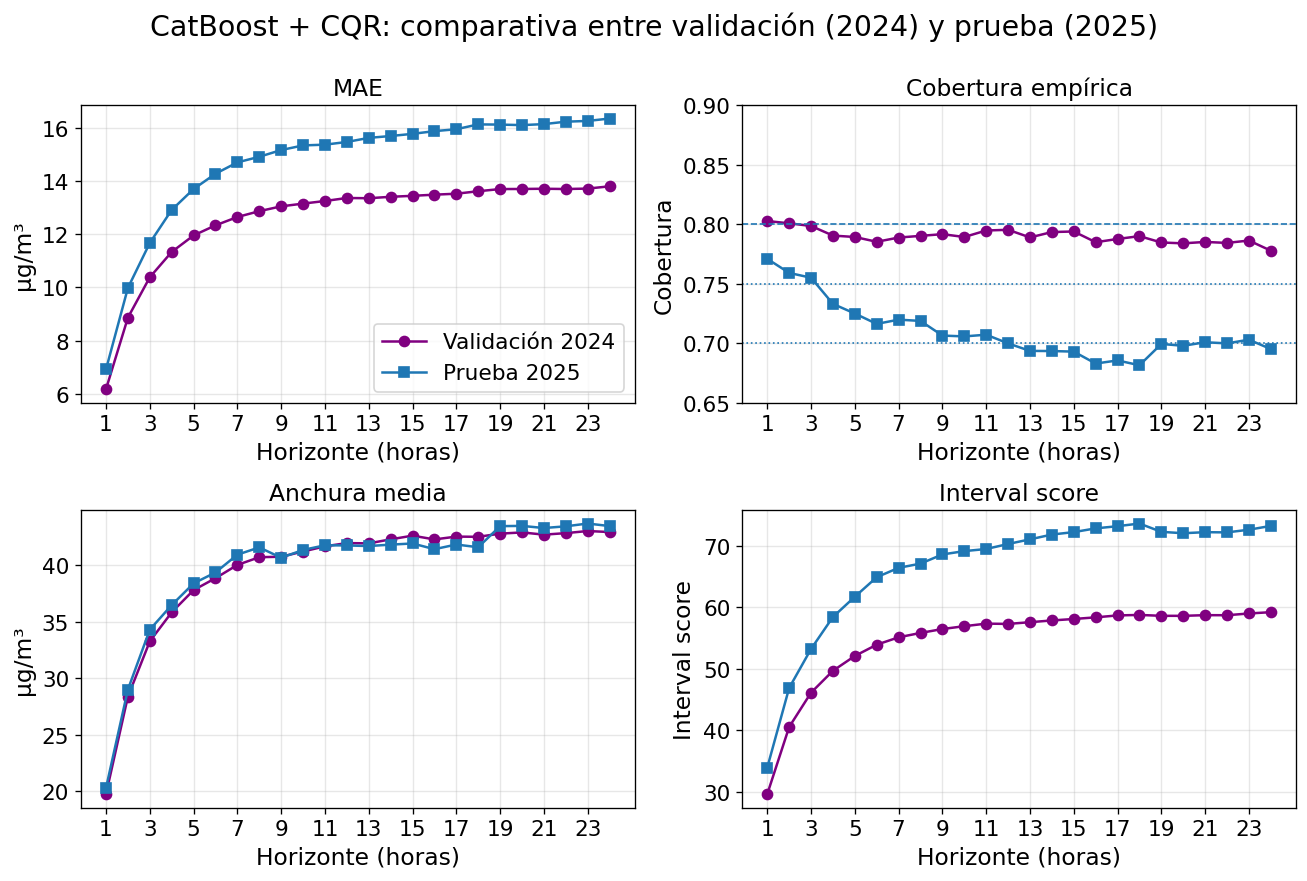

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.3))
axes = axes.ravel()

metric_specs = [
    ("mae", "MAE", "µg/m³"),
    ("empirical_coverage", "Cobertura empírica", "Cobertura"),
    ("mean_width", "Anchura media", "µg/m³"),
    ("mean_interval_score", "Interval score", "Interval score"),
]

for ax, (metric, title, ylabel) in zip(axes, metric_specs):
    ax.plot(validation_metrics_df["horizon"], validation_metrics_df[metric], marker="o", label="Validación 2024", color="purple")
    ax.plot(test_metrics_df["horizon"], test_metrics_df[metric], marker="s", label="Prueba 2025")
    if metric == "empirical_coverage":
        ax.axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1, label="Cobertura nominal")
        ax.axhline(HIGH_COVERAGE_THRESHOLD, linestyle=":", linewidth=1, label="Umbral 0,75")
        ax.axhline(MODERATE_COVERAGE_THRESHOLD, linestyle=":", linewidth=1, label="Umbral 0,70")
        ax.set_ylim(0.65, 0.90)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Horizonte (horas)", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(range(1, 25, 2))
    ax.tick_params(axis='both', labelsize=13)
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=13)
fig.suptitle("CatBoost + CQR: comparativa entre validación (2024) y prueba (2025)", y=1, fontsize=17)
fig.tight_layout()

validation_test_figure_path = save_figure(
    fig,
    REPORTS_FIGURES_DIR / "frontier_validation_2024_vs_test_2025_metrics.png",
)
plt.show()


## Descomposición de la degradación por horizonte

La siguiente figura muestra cómo evolucionan los componentes normalizados de la puntuación $F(h)$ sobre el conjunto de prueba. Esta figura permite, pues, ver si la degradación se debe principalmente al error puntual, al *interval score* o al déficit de cobertura.


Figura guardada: c:\trabajo_github\reports\figures\frontier_test_2025_score_by_horizon.png


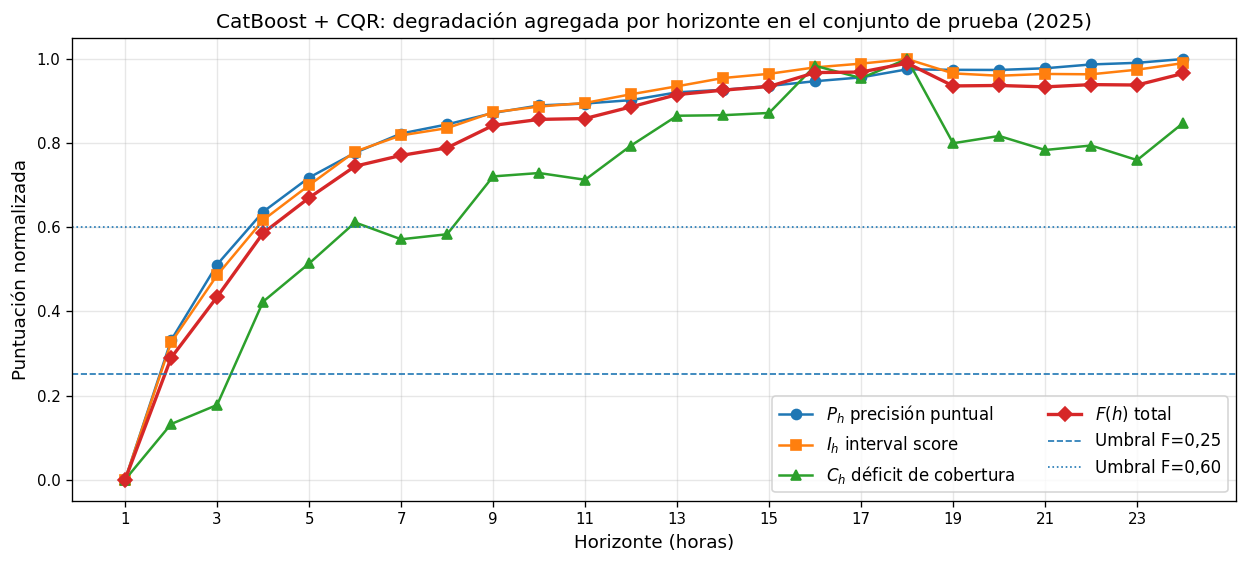

In [10]:
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.plot(test_score_df["horizon"], test_score_df["P_h"], marker="o", label=r"$P_h$ precisión puntual")
ax.plot(test_score_df["horizon"], test_score_df["I_h"], marker="s", label=r"$I_h$ interval score")
ax.plot(test_score_df["horizon"], test_score_df["C_h"], marker="^", label=r"$C_h$ déficit de cobertura")
ax.plot(test_score_df["horizon"], test_score_df["F_h"], marker="D", linewidth=2.0, label=r"$F(h)$ total")
ax.axhline(HIGH_FRONTIER_SCORE_THRESHOLD, linestyle="--", linewidth=1, label="Umbral F=0,25")
ax.axhline(MODERATE_FRONTIER_SCORE_THRESHOLD, linestyle=":", linewidth=1, label="Umbral F=0,60")
ax.set_xlabel("Horizonte (horas)")
ax.set_ylabel("Puntuación normalizada")
ax.set_title("CatBoost + CQR: degradación agregada por horizonte en el conjunto de prueba (2025)")
ax.set_xticks(range(1, 25, 2))
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()

score_figure_path = save_figure(
    fig,
    REPORTS_FIGURES_DIR / "frontier_test_2025_score_by_horizon.png",
)
plt.show()


## Dirección de los fallos de cobertura

Cuando el intervalo no contiene el valor observado, resultaría muy interesante distinguir si el fallo se produce por debajo del límite inferior o por encima del límite superior. En este problema, los fallos por encima del intervalo son especialmente relevantes, porque indican que el sistema está subestimando episodios elevados de $O_3$.


Tabla guardada: c:\trabajo_github\reports\tables\frontier_test_2025_miss_direction_by_horizon.csv


,horizon,miss_lower_pct,miss_upper_pct,miss_total_pct,upper_miss_share
0,1,9.0920,13.8289,22.9209,0.6033
1,2,8.6028,15.4993,24.1021,0.6431
2,3,8.3284,16.1795,24.5078,0.6602
3,4,8.1255,18.5777,26.7033,0.6957
7,8,7.3500,20.7851,28.1351,0.7388
10,11,6.8727,22.4198,29.2924,0.7654
11,12,7.2784,22.7419,30.0203,0.7576
17,18,6.9681,24.8896,31.8578,0.7813
23,24,6.1329,24.3646,30.4976,0.7989


Figura guardada: c:\trabajo_github\reports\figures\frontier_test_2025_miss_direction.png


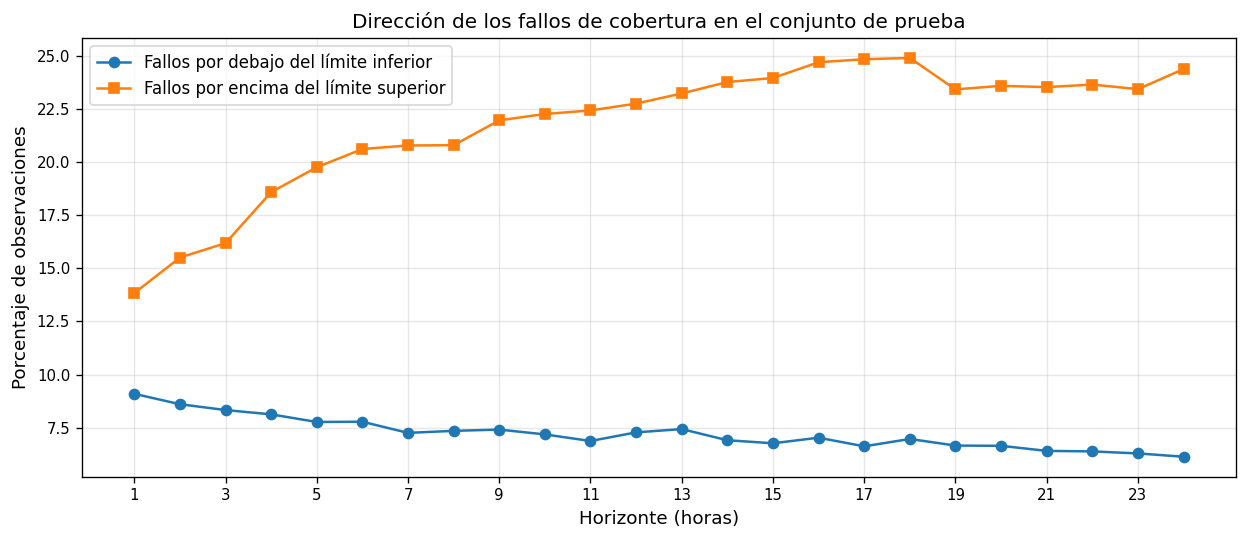

In [11]:
miss_direction_df = test_diagnostics_df.loc[
    :,
    ["horizon", "miss_lower_pct", "miss_upper_pct", "miss_total_pct", "upper_miss_share"],
].copy()

miss_direction_path = save_dataframe_csv(
    miss_direction_df,
    REPORTS_TABLES_DIR / "frontier_test_2025_miss_direction_by_horizon.csv",
    index=False,
)

display(miss_direction_df.loc[miss_direction_df["horizon"].isin(COMPACT_HORIZONS)])

fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.plot(miss_direction_df["horizon"], miss_direction_df["miss_lower_pct"], marker="o", label="Fallos por debajo del límite inferior")
ax.plot(miss_direction_df["horizon"], miss_direction_df["miss_upper_pct"], marker="s", label="Fallos por encima del límite superior")
ax.set_xlabel("Horizonte (horas)")
ax.set_ylabel("Porcentaje de observaciones")
ax.set_title("Dirección de los fallos de cobertura en el conjunto de prueba")
ax.set_xticks(range(1, 25, 2))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

miss_direction_figure_path = save_figure(
    fig,
    REPORTS_FIGURES_DIR / "frontier_test_2025_miss_direction.png",
)
plt.show()


## Determinación operativa de la frontera temporal

La frontera temporal de utilidad se determina combinando la puntuación agregada $F(h)$ con la cobertura empírica. La cobertura actúa como condición de fiabilidad, mientras que $F(h)$ resume conjuntamente el error puntual, el *interval score* y el déficit de cobertura.

Se aplican tres niveles:

- Utilidad alta: cobertura $\geq 0{,}75$ y $F(h) \leq 0{,}25$
- Utilidad moderada: cobertura $\geq 0{,}70$ y $F(h) \leq 0{,}60$
- Utilidad limitada: el horizonte no cumple ninguna de las condiciones anteriores

La frontera deberá ser progresiva: no se aceptará un horizonte aislado si algún horizonte anterior ha dejado de cumplir el criterio previamente establecido.


In [12]:
def classify_utility(row: pd.Series) -> str:
    """Clasifica la utilidad de un horizonte según la cobertura y la F(h)."""
    if (row["empirical_coverage"] >= HIGH_COVERAGE_THRESHOLD) and (row["F_h"] <= HIGH_FRONTIER_SCORE_THRESHOLD):
        return "Alta"
    if (row["empirical_coverage"] >= MODERATE_COVERAGE_THRESHOLD) and (row["F_h"] <= MODERATE_FRONTIER_SCORE_THRESHOLD):
        return "Moderada"
    return "Limitada"


def decision_reason(row: pd.Series) -> str:
    """Explicación breve de la utilidad por horizonte."""
    reasons = []
    if row["empirical_coverage"] < MODERATE_COVERAGE_THRESHOLD:
        reasons.append("cobertura < 0,70")
    elif row["empirical_coverage"] < HIGH_COVERAGE_THRESHOLD:
        reasons.append("cobertura < 0,75")
    if row["F_h"] > MODERATE_FRONTIER_SCORE_THRESHOLD:
        reasons.append("F(h) > 0,60")
    elif row["F_h"] > HIGH_FRONTIER_SCORE_THRESHOLD:
        reasons.append("F(h) > 0,25")
    if not reasons:
        return "cumple criterios de utilidad alta"
    return "; ".join(reasons)


frontier_df = test_diagnostics_df.copy()
frontier_df["utility_level"] = frontier_df.apply(classify_utility, axis=1)
frontier_df["decision_reason"] = frontier_df.apply(decision_reason, axis=1)
frontier_df["high_utility_ok"] = frontier_df["utility_level"].eq("Alta")
frontier_df["moderate_or_high_utility_ok"] = frontier_df["utility_level"].isin(["Alta", "Moderada"])

strict_frontier = contiguous_frontier(frontier_df, "high_utility_ok")
moderate_frontier = contiguous_frontier(frontier_df, "moderate_or_high_utility_ok")

frontier_path = save_dataframe_csv(
    frontier_df,
    REPORTS_TABLES_DIR / "frontier_decision_by_horizon.csv",
    index=False,
)

frontier_summary_df = pd.DataFrame(
    [
        {
            "criterion": "Frontera estricta",
            "definition": f"Cobertura >= {HIGH_COVERAGE_THRESHOLD:.2f} y F(h) <= {HIGH_FRONTIER_SCORE_THRESHOLD:.2f}, de forma contigua desde h=1",
            "frontier_horizon": strict_frontier,
        },
        {
            "criterion": "Frontera moderada",
            "definition": f"Cobertura >= {MODERATE_COVERAGE_THRESHOLD:.2f} y F(h) <= {MODERATE_FRONTIER_SCORE_THRESHOLD:.2f}, de forma contigua desde h=1",
            "frontier_horizon": moderate_frontier,
        },
    ]
)

frontier_summary_path = save_dataframe_csv(
    frontier_summary_df,
    REPORTS_TABLES_DIR / "frontier_summary.csv",
    index=False,
)

print("Resumen de frontera temporal:")
display(frontier_summary_df)

print("Diagnóstico por horizonte:")
display(frontier_df[["horizon", "mae", "rmse", "empirical_coverage", "mean_width", "mean_interval_score", "F_h", "utility_level", "decision_reason"]])


Tabla guardada: c:\trabajo_github\reports\tables\frontier_decision_by_horizon.csv
Tabla guardada: c:\trabajo_github\reports\tables\frontier_summary.csv
Resumen de frontera temporal:


,criterion,definition,frontier_horizon
0,Frontera estricta,"Cobertura >= 0.75 y F(h) <= 0.25, de forma con...",1
1,Frontera moderada,"Cobertura >= 0.70 y F(h) <= 0.60, de forma con...",4


Diagnóstico por horizonte:


,horizon,mae,rmse,empirical_coverage,mean_width,mean_interval_score,F_h,utility_level,decision_reason
0,1,6.9163,9.7275,0.7708,20.2810,33.9467,0.0000,Alta,cumple criterios de utilidad alta
1,2,9.9838,13.3969,0.7590,29.0042,46.9056,0.2895,Moderada,"F(h) > 0,25"
2,3,11.6772,15.3566,0.7549,34.3082,53.2488,0.4345,Moderada,"F(h) > 0,25"
3,4,12.9218,16.6476,0.7330,36.4896,58.4566,0.5862,Moderada,"cobertura < 0,75; F(h) > 0,25"
4,5,13.7086,17.5090,0.7249,38.4094,61.7486,0.6701,Limitada,"cobertura < 0,75; F(h) > 0,60"
5,6,14.2854,18.1275,0.7161,39.3781,64.9267,0.7452,Limitada,"cobertura < 0,75; F(h) > 0,60"
6,7,14.7126,18.6282,0.7197,40.9543,66.4512,0.7708,Limitada,"cobertura < 0,75; F(h) > 0,60"
7,8,14.9243,18.8558,0.7186,41.5994,67.1370,0.7888,Limitada,"cobertura < 0,75; F(h) > 0,60"
8,9,15.1771,19.1551,0.7064,40.6810,68.6299,0.8422,Limitada,"cobertura < 0,75; F(h) > 0,60"
9,10,15.3518,19.3440,0.7056,41.3748,69.1722,0.8565,Limitada,"cobertura < 0,75; F(h) > 0,60"


In [13]:
frontier_csv_df = frontier_df.loc[frontier_df["horizon"].isin(COMPACT_HORIZONS)].copy()

frontier_csv_df = frontier_csv_df.rename(
    columns={
        "horizon": "Horizonte",
        "mae": "MAE",
        "rmse": "RMSE",
        "empirical_coverage": "Cobertura",
        "mean_width": "Anchura",
        "mean_interval_score": "IS",
        "F_h": "F(h)",
        "miss_upper_pct": "Fallos sup. (%)",
        "utility_level": "Dictamen",
    }
)

frontier_csv_df = frontier_csv_df[
    [
        "Horizonte",
        "MAE",
        "RMSE",
        "Cobertura",
        "Anchura",
        "IS",
        "F(h)",
        "Fallos sup. (%)",
        "Dictamen",
    ]
]

frontier_csv_df["Horizonte"] = frontier_csv_df["Horizonte"].astype(int).astype(str) + " h"

for col in ["MAE", "RMSE", "Anchura", "IS", "F(h)"]:
    frontier_csv_df[col] = frontier_csv_df[col].map(lambda x: format_es(x, 3))

frontier_csv_df["Cobertura"] = frontier_csv_df["Cobertura"].map(lambda x: format_es(x, 3))
frontier_csv_df["Fallos sup. (%)"] = frontier_csv_df["Fallos sup. (%)"].map(lambda x: format_es(x, 2))

frontier_csv_path = save_dataframe_csv(
    frontier_csv_df,
    REPORTS_TABLES_DIR / "frontier_decision_compact_formatted.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig",
)

display(frontier_csv_df)

Tabla guardada: c:\trabajo_github\reports\tables\frontier_decision_compact_formatted.csv


,Horizonte,MAE,RMSE,Cobertura,Anchura,IS,F(h),Fallos sup. (%),Dictamen
0,1 h,"6,916","9,727","0,771","20,281","33,947","0,000","13,83",Alta
1,2 h,"9,984","13,397","0,759","29,004","46,906","0,290","15,50",Moderada
2,3 h,"11,677","15,357","0,755","34,308","53,249","0,434","16,18",Moderada
3,4 h,"12,922","16,648","0,733","36,490","58,457","0,586","18,58",Moderada
7,8 h,"14,924","18,856","0,719","41,599","67,137","0,789","20,79",Limitada
10,11 h,"15,380","19,409","0,707","41,785","69,516","0,859","22,42",Limitada
11,12 h,"15,482","19,468","0,700","41,772","70,334","0,886","22,74",Limitada
17,18 h,"16,144","20,296","0,681","41,612","73,661","0,990","24,89",Limitada
23,24 h,"16,365","20,574","0,695","43,490","73,274","0,966","24,36",Limitada


Figura guardada: c:\trabajo_github\reports\figures\frontier_test_2025_metrics_with_frontier.png


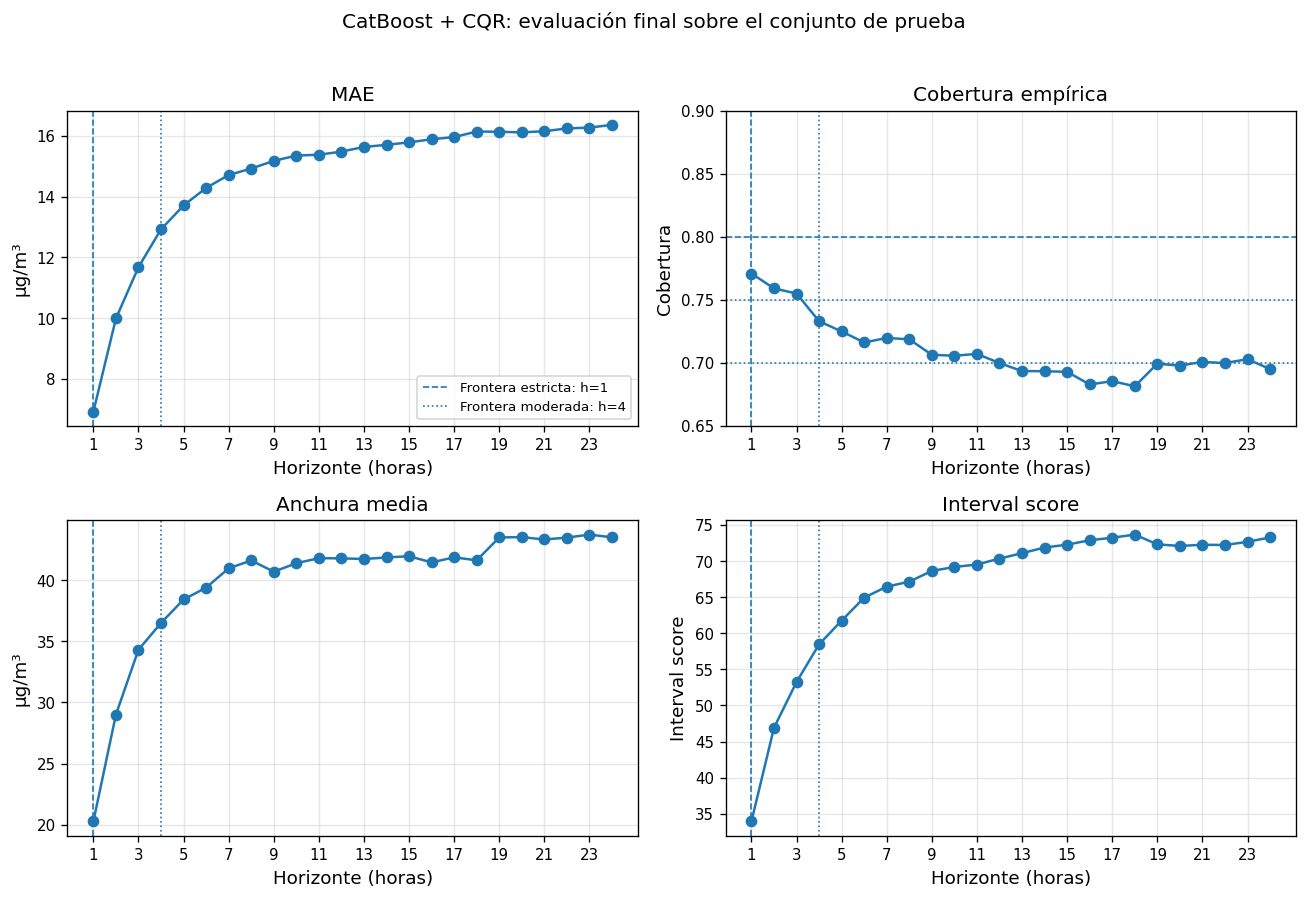

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.3))
axes = axes.ravel()

metric_specs = [
    ("mae", "MAE", "µg/m³"),
    ("empirical_coverage", "Cobertura empírica", "Cobertura"),
    ("mean_width", "Anchura media", "µg/m³"),
    ("mean_interval_score", "Interval score", "Interval score"),
]

for ax, (metric, title, ylabel) in zip(axes, metric_specs):
    ax.plot(frontier_df["horizon"], frontier_df[metric], marker="o")
    if strict_frontier is not None:
        ax.axvline(strict_frontier, linestyle="--", linewidth=1, label=f"Frontera estricta: h={strict_frontier}")
    if moderate_frontier is not None:
        ax.axvline(moderate_frontier, linestyle=":", linewidth=1, label=f"Frontera moderada: h={moderate_frontier}")
    if metric == "empirical_coverage":
        ax.axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1, label="Cobertura nominal")
        ax.axhline(HIGH_COVERAGE_THRESHOLD, linestyle=":", linewidth=1, label="Umbral 0,75")
        ax.axhline(MODERATE_COVERAGE_THRESHOLD, linestyle=":", linewidth=1, label="Umbral 0,70")
        ax.set_ylim(0.65, 0.90)
    ax.set_title(title)
    ax.set_xlabel("Horizonte (horas)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 25, 2))
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8)
fig.suptitle("CatBoost + CQR: evaluación final sobre el conjunto de prueba", y=1.02)
fig.tight_layout()

test_metrics_figure_path = save_figure(
    fig,
    REPORTS_FIGURES_DIR / "frontier_test_2025_metrics_with_frontier.png",
)
plt.show()


## Visualización de intervalos en un tramo continuo del conjunto de prueba

La figura siguiente contiene un tramo que se selecciona automáticamente mediante un criterio reproducible y con una restricción estricta de continuidad, de forma similar a como se efectuaba en el notebook 05: para los horizontes representados $h=1$, $h=4$ y $h=24$, todos los timestamps horarios del tramo deben existir y contar con un valor de observación, una predicción central y tener los límites calibrados.

In [15]:

def resolve_visual_split(intervals_df: pd.DataFrame, preferred: str = "test") -> str:
    available = {str(x).lower(): x for x in intervals_df["split"].dropna().unique()}
    for candidate in [preferred, "test_2025", "prueba", "prueba_2025"]:
        if candidate.lower() in available:
            return available[candidate.lower()]
    raise ValueError(
        "No se encontró un conjunto de de prueba en los intervalos. "
        f"Splits disponibles: {sorted(intervals_df['split'].dropna().unique())}"
    )

def interval_score_mean(y: pd.Series, lower: pd.Series, upper: pd.Series, alpha: float = ALPHA) -> float:
    """Calcula el interval score medio para un tramo."""
    y = pd.Series(y, dtype=float)
    lower = pd.Series(lower, dtype=float)
    upper = pd.Series(upper, dtype=float)
    width = upper - lower
    penalty_lower = (2.0 / alpha) * (lower - y) * (y < lower)
    penalty_upper = (2.0 / alpha) * (y - upper) * (y > upper)
    return float((width + penalty_lower + penalty_upper).mean())

def valid_timestamps_for_horizon(intervals_df: pd.DataFrame, split: str, horizon: int) -> pd.DatetimeIndex:
    valid = intervals_df.loc[
        (intervals_df["split"] == split) & (intervals_df["horizon"] == horizon),
        ["target_timestamp", "y_true", "y_pred_central", "lower", "upper"],
    ].copy()
    valid = valid.dropna(subset=["target_timestamp", "y_true", "y_pred_central", "lower", "upper"])
    valid["target_timestamp"] = pd.to_datetime(valid["target_timestamp"])
    # Si hubiera duplicados, se conserva un único registro por timestamp.
    return pd.DatetimeIndex(valid["target_timestamp"].drop_duplicates().sort_values())

def contiguous_runs_from_index(index: pd.DatetimeIndex) -> list[tuple[pd.Timestamp, pd.Timestamp, int]]:
    """Identifica tramos horarios continuos."""
    if len(index) == 0:
        return []
    idx = pd.DatetimeIndex(index).sort_values()
    runs: list[tuple[pd.Timestamp, pd.Timestamp, int]] = []
    start = idx[0]
    prev = idx[0]
    count = 1
    for ts in idx[1:]:
        if ts - prev == pd.Timedelta(hours=1):
            count += 1
        else:
            runs.append((pd.Timestamp(start), pd.Timestamp(prev), count))
            start = ts
            count = 1
        prev = ts
    runs.append((pd.Timestamp(start), pd.Timestamp(prev), count))
    return runs

def get_strict_window_block(
    intervals_df: pd.DataFrame,
    split: str,
    horizon: int,
    start: pd.Timestamp,
    end: pd.Timestamp,
) -> pd.DataFrame:
    """Extrae un tramo y verifica que no tenga huecos."""
    expected_index = pd.date_range(start, end, freq="1h")
    block = intervals_df.loc[
        (intervals_df["split"] == split)
        & (intervals_df["horizon"] == horizon)
        & (intervals_df["target_timestamp"] >= start)
        & (intervals_df["target_timestamp"] <= end),
        ["target_timestamp", "y_true", "y_pred_central", "lower", "upper"],
    ].copy()
    block = block.dropna(subset=["target_timestamp", "y_true", "y_pred_central", "lower", "upper"])
    block["target_timestamp"] = pd.to_datetime(block["target_timestamp"])
    block = block.drop_duplicates(subset=["target_timestamp"]).sort_values("target_timestamp")
    block = block.set_index("target_timestamp").reindex(expected_index)
    if block[["y_true", "y_pred_central", "lower", "upper"]].isna().any().any():
        raise ValueError(
            f"El tramo {start} → {end} no es continuo para split={split}, h={horizon}."
        )
    block = block.reset_index().rename(columns={"index": "target_timestamp"})
    block["split"] = split
    block["horizon"] = horizon
    return block

def select_test_visual_window(
    intervals_df: pd.DataFrame,
    split: str,
    horizons: list[int] = VISUAL_HORIZONS,
    selection_horizon: int = 24,
    window_days_options: tuple[int, ...] = (14, 10, 7, 5),
) -> tuple[pd.Timestamp, pd.Timestamp, int, pd.DataFrame]:
    valid_indices = [valid_timestamps_for_horizon(intervals_df, split, h) for h in horizons]
    if any(len(idx) == 0 for idx in valid_indices):
        raise ValueError(f"No hay datos válidos para todos los horizontes {horizons} en split={split}.")

    # Intersección de timestamps válidos entre todos los horizontes representados.
    common_idx = valid_indices[0]
    for idx in valid_indices[1:]:
        common_idx = common_idx.intersection(idx)
    common_idx = pd.DatetimeIndex(common_idx).sort_values()

    if common_idx.empty:
        raise ValueError("No hay observaciones comunes válidas entre los horizontes seleccionados.")

    runs = contiguous_runs_from_index(common_idx)
    candidates_all = []

    for window_days in window_days_options:
        window_hours = int(window_days * 24)
        candidates = []

        for run_start, run_end, run_len in runs:
            if run_len < window_hours:
                continue
            latest_start = run_end - pd.Timedelta(hours=window_hours - 1)
            start_candidates = pd.date_range(run_start.floor("D"), latest_start, freq="24h")
            start_candidates = [s for s in start_candidates if s >= run_start and s <= latest_start]
            # Si el tramo continuo no empieza a medianoche, se añade también el primer inicio posible.
            if run_start not in start_candidates and run_start <= latest_start:
                start_candidates = [run_start] + start_candidates

            for start in start_candidates:
                end = start + pd.Timedelta(hours=window_hours - 1)
                try:
                    # La llamada verifica la continuidad estricta para el horizonte de selección.
                    window = get_strict_window_block(intervals_df, split, selection_horizon, start, end)
                    # Y verificamos también el resto de horizontes visuales.
                    for h in horizons:
                        if h != selection_horizon:
                            _ = get_strict_window_block(intervals_df, split, h, start, end)
                except ValueError:
                    continue

                p90 = float(window["y_true"].quantile(0.90))
                mae = float(np.mean(np.abs(window["y_true"] - window["y_pred_central"])))
                coverage = float(((window["y_true"] >= window["lower"]) & (window["y_true"] <= window["upper"])).mean())
                mean_width = float((window["upper"] - window["lower"]).mean())
                is_mean = interval_score_mean(window["y_true"], window["lower"], window["upper"], alpha=ALPHA)

                candidates.append(
                    {
                        "window_days": window_days,
                        "start": start,
                        "end": end,
                        "n_hours": len(window),
                        "p90_o3": p90,
                        "mae_h24": mae,
                        "coverage_h24": coverage,
                        "mean_width_h24": mean_width,
                        "interval_score_h24": is_mean,
                    }
                )

        if candidates:
            candidates_df = pd.DataFrame(candidates)
            high_threshold = candidates_df["p90_o3"].quantile(0.75)
            high_candidates = candidates_df.loc[candidates_df["p90_o3"] >= high_threshold].copy()
            median_is = high_candidates["interval_score_h24"].median()
            high_candidates["distance_to_median_is"] = (high_candidates["interval_score_h24"] - median_is).abs()
            high_candidates["distance_to_global_coverage"] = (high_candidates["coverage_h24"] - candidates_df["coverage_h24"].median()).abs()

            selected = high_candidates.sort_values(
                ["distance_to_median_is", "distance_to_global_coverage", "start"]
            ).iloc[0]

            return (
                pd.Timestamp(selected["start"]),
                pd.Timestamp(selected["end"]),
                int(selected["window_days"]),
                candidates_df,
            )

        candidates_all.append(pd.DataFrame(candidates))

    raise ValueError(
        "No se encontró ningún tramo continuo sin huecos para las duraciones probadas "
    )


if not intervals_path.exists():
    raise FileNotFoundError(
        f"No se encontró {intervals_path}. Ejecuta primero el notebook 09 para generar los intervalos de 1 a 24."
    )

intervals_df = pd.read_parquet(intervals_path).copy()
intervals_df = normalize_interval_columns(intervals_df)
intervals_df["target_timestamp"] = pd.to_datetime(intervals_df["target_timestamp"])
intervals_df["horizon"] = intervals_df["horizon"].astype(int)

required_interval_cols = {"split", "horizon", "target_timestamp", "y_true", "y_pred_central", "lower", "upper"}
missing_interval_cols = required_interval_cols - set(intervals_df.columns)
if missing_interval_cols:
    raise ValueError(f"Faltan columnas en el parquet de intervalos: {sorted(missing_interval_cols)}")

visual_split = resolve_visual_split(intervals_df, preferred="test")
visual_start, visual_end, visual_window_days, visual_window_candidates_df = select_test_visual_window(
    intervals_df,
    split=visual_split,
    horizons=VISUAL_HORIZONS,
    selection_horizon=24,
    window_days_options=(14, 10, 7, 5),
)

visual_candidates_path = save_dataframe_csv(
    visual_window_candidates_df,
    REPORTS_TABLES_DIR / "frontier_visual_window_candidates_test_2025.csv",
    index=False,
)

selected_visual_window_df = pd.DataFrame(
    [{"split": visual_split, "start": visual_start, "end": visual_end, "window_days": visual_window_days, "selection_horizon": 24}]
)
selected_visual_window_path = save_dataframe_csv(
    selected_visual_window_df,
    REPORTS_TABLES_DIR / "frontier_visual_window_selected_test_2025.csv",
    index=False,
)

print("El tramo visual continuo de prueba (2025) se ha seleccionado automáticamente.")
print(f"Tramo visual: {visual_start} → {visual_end} ({visual_window_days} días, sin huecos horarios)")
print(f"Conjunto usado en la figura: {visual_split}")


Tabla guardada: c:\trabajo_github\reports\tables\frontier_visual_window_candidates_test_2025.csv
Tabla guardada: c:\trabajo_github\reports\tables\frontier_visual_window_selected_test_2025.csv
El tramo visual continuo de prueba (2025) se ha seleccionado automáticamente.
Tramo visual: 2025-06-10 00:00:00 → 2025-06-23 23:00:00 (14 días, sin huecos horarios)
Conjunto usado en la figura: test


Figura guardada: c:\trabajo_github\reports\figures\frontier_catboost_cqr_intervals_test_2025_continuous_window.png


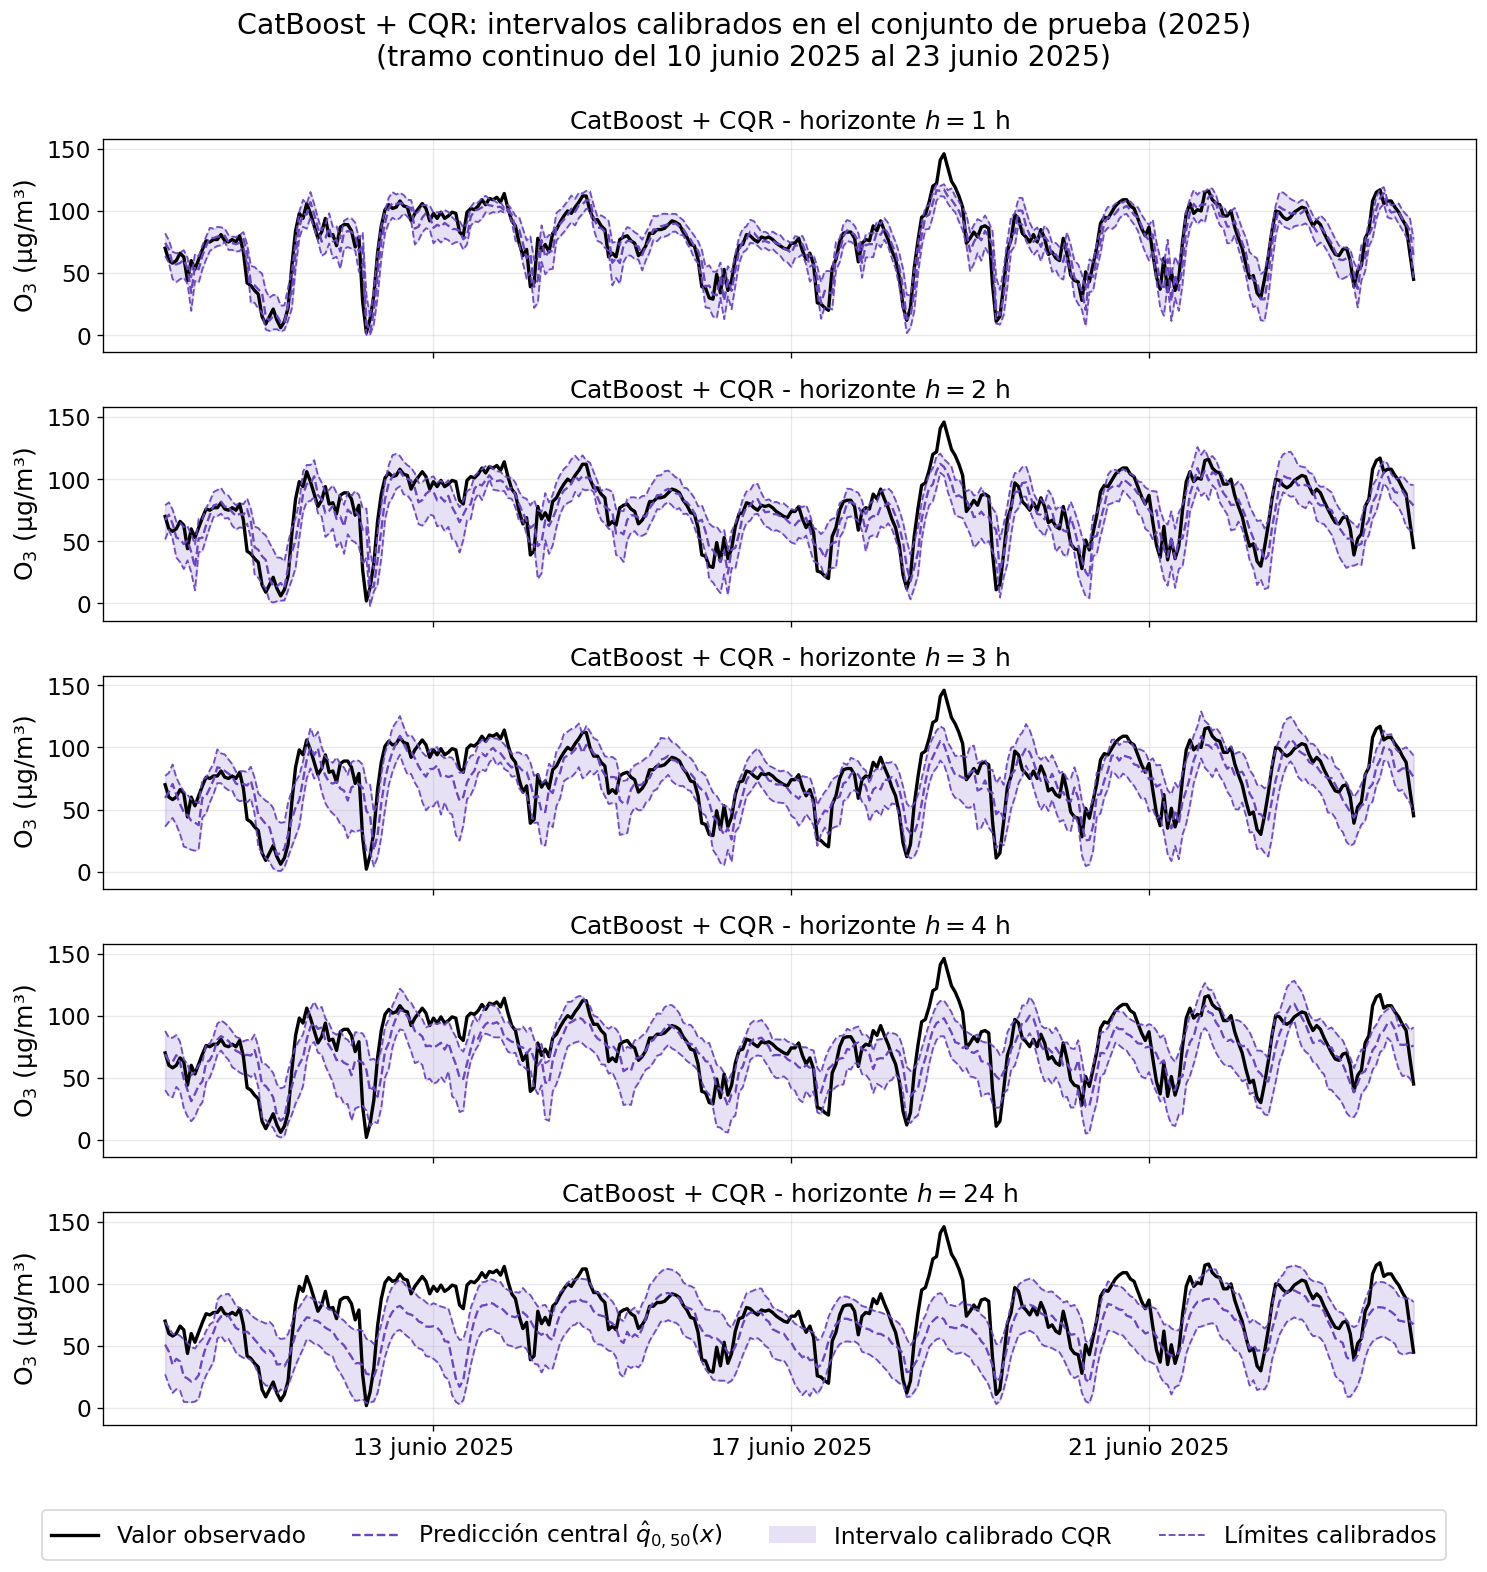

In [16]:

fig, axes = plt.subplots(len(VISUAL_HORIZONS), 1, figsize=(12.5, 13), sharex=True)
if len(VISUAL_HORIZONS) == 1:
    axes = [axes]

purple = "#6B46C1"
fill_alpha = 0.16
all_blocks = []

for horizon in VISUAL_HORIZONS:
    h_df = get_strict_window_block(intervals_df, visual_split, horizon, visual_start, visual_end)
    if h_df.empty:
        raise ValueError(f"No hay datos para h={horizon} en el tramo visual seleccionado.")
    all_blocks.append(h_df)

# Rango vertical común para facilitar la comparación entre horizontes.
y_values = pd.concat([block[["y_true", "y_pred_central", "lower", "upper"]].stack() for block in all_blocks]).dropna()
y_min = float(y_values.min())
y_max = float(y_values.max())
y_margin = max(5.0, 0.08 * (y_max - y_min))
y_limits = (y_min - y_margin, y_max + y_margin)

for ax, horizon, h_df in zip(axes, VISUAL_HORIZONS, all_blocks):
    x = h_df["target_timestamp"]
    ax.plot(x, h_df["y_true"], color="black", linewidth=2.0, label="Valor observado")
    ax.plot(x, h_df["y_pred_central"], color=purple, linestyle="--", linewidth=1.4, label=r"Predicción central $\hat{q}_{0,50}(x)$")
    ax.fill_between(x, h_df["lower"], h_df["upper"], color=purple, alpha=fill_alpha, label="Intervalo calibrado CQR")
    ax.plot(x, h_df["lower"], color=purple, linestyle="--", linewidth=1.1, alpha=0.95, label="Límites calibrados")
    ax.plot(x, h_df["upper"], color=purple, linestyle="--", linewidth=1.1, alpha=0.95)
    ax.set_title(rf"CatBoost + CQR - horizonte $h = {horizon}$ h", fontsize=15)
    ax.set_ylabel(r"O$_3$ (µg/m³)", fontsize=15)
    ax.set_ylim(*y_limits)
    ax.grid(True, alpha=0.28)

#axes[-1].set_xlabel("Fecha objetivo")
locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(FuncFormatter(spanish_axis_date))
    ax.tick_params(axis='both', labelsize=14)
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
for ax in axes[-1:]:
    ax.tick_params(axis="x", rotation=0)

legend_handles = [
    Line2D([0], [0], color="black", linewidth=2.0, label="Valor observado"),
    Line2D([0], [0], color=purple, linestyle="--", linewidth=1.4, label=r"Predicción central $\hat{q}_{0,50}(x)$"),
    Patch(facecolor=purple, alpha=fill_alpha, edgecolor="none", label="Intervalo calibrado CQR"),
    Line2D([0], [0], color=purple, linestyle="--", linewidth=1.1, label="Límites calibrados"),
]

fig.suptitle(
    "CatBoost + CQR: intervalos calibrados en el conjunto de prueba (2025)\n"
    f"(tramo continuo del {format_spanish_date(visual_start)} al {format_spanish_date(visual_end)})",
    y=0.98, fontsize=17,
)
fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=True, bbox_to_anchor=(0.5, -0.02), fontsize=14)
fig.tight_layout(rect=(0, 0.04, 1, 0.98))

visual_intervals_figure_path = save_figure(
    fig,
    REPORTS_FIGURES_DIR / "frontier_catboost_cqr_intervals_test_2025_continuous_window.png",
)
plt.show()


GIF: se reutiliza el tramo visual continuo ya seleccionado para la figura estática.
Tabla guardada: c:\trabajo_github\reports\tables\frontier_catboost_cqr_intervals_test_2025_horizons_01_20_metadata.csv
GIF guardado: c:\trabajo_github\reports\figures\frontier_catboost_cqr_intervals_test_2025_horizons_01_20.gif
Horizontes incluidos: 1-23
Tramo usado: 2025-06-10 00:00:00 → 2025-06-23 23:00:00 (14 días)
Frontera estricta: h=1; frontera moderada: h=4


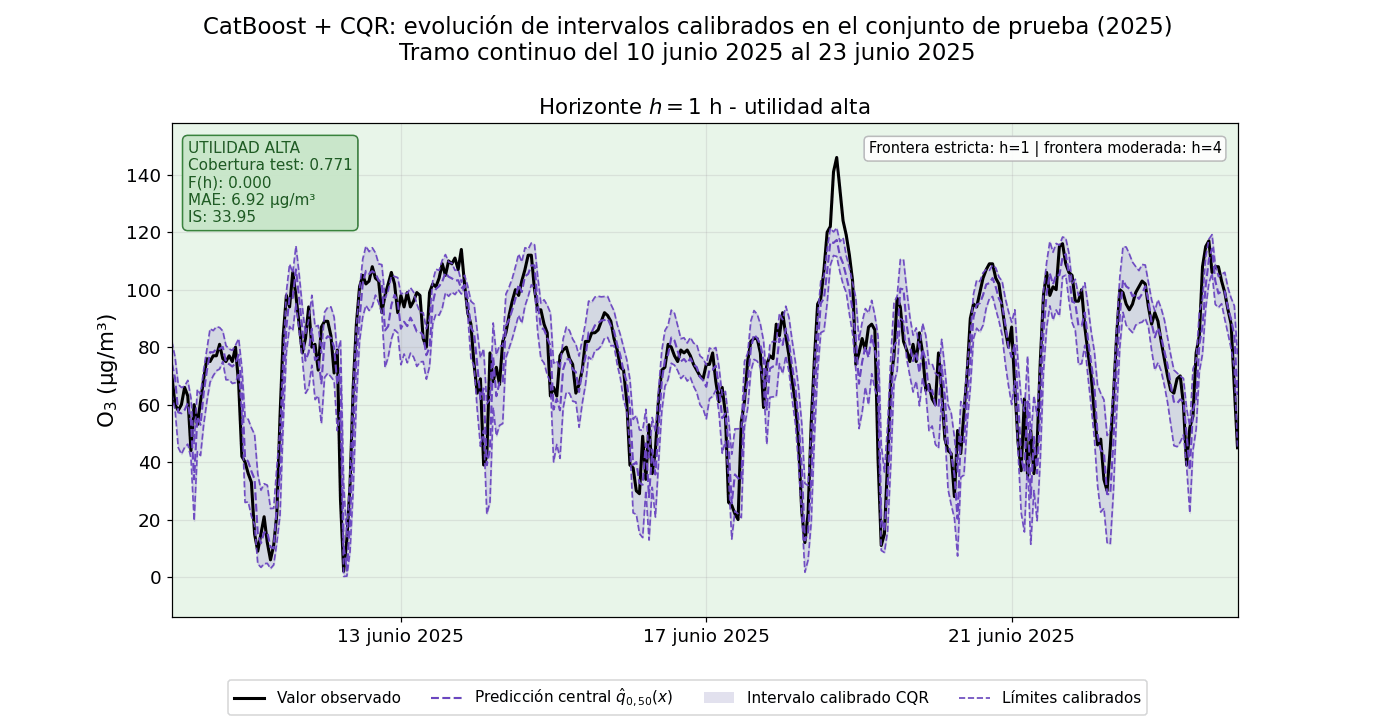

In [17]:
# GIF animado.

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

# Horizonte máximo del GIF. Se puede subir a 24 si uno quiere mostrar todo el rango.
GIF_HORIZONS = list(range(1, 24))
GIF_FPS = 2
GIF_PAUSE_SECONDS = 1.5
GIF_DPI = 110

GIF_OUTPUT_PATH = REPORTS_FIGURES_DIR / "frontier_catboost_cqr_intervals_test_2025_horizons_01_20.gif"
GIF_METADATA_PATH = REPORTS_TABLES_DIR / "frontier_catboost_cqr_intervals_test_2025_horizons_01_20_metadata.csv"

UTILITY_STYLES = {
    "Alta": {
        "background": "#E8F5E9",
        "box_face": "#C8E6C9",
        "box_edge": "#2E7D32",
        "text": "#1B5E20",
        "label": "utilidad alta",
    },
    "Moderada": {
        "background": "#FFF8E1",
        "box_face": "#FFECB3",
        "box_edge": "#F9A825",
        "text": "#7A5A00",
        "label": "utilidad moderada",
    },
    "Limitada": {
        "background": "#FFEBEE",
        "box_face": "#FFCDD2",
        "box_edge": "#C62828",
        "text": "#B71C1C",
        "label": "utilidad limitada",
    },
}

if "frontier_df" not in globals():
    raise RuntimeError("Debe ejecutarse antes la celda de determinación de la frontera temporal.")
if "intervals_df" not in globals() or "visual_split" not in globals():
    raise RuntimeError("Debe ejecutarse antes la celda de selección del tramo visual de prueba de 2025.")

frontier_lookup = (
    frontier_df.set_index("horizon")
    [["utility_level", "empirical_coverage", "F_h", "mae", "mean_width", "mean_interval_score"]]
    .to_dict(orient="index")
)

missing_horizons = [h for h in GIF_HORIZONS if h not in frontier_lookup]
if missing_horizons:
    raise ValueError(f"Faltan horizontes en frontier_df para construir el GIF: {missing_horizons}")

try:
    gif_start = visual_start
    gif_end = visual_end
    gif_window_days = visual_window_days
    gif_blocks = {
        h: get_strict_window_block(intervals_df, visual_split, h, gif_start, gif_end)
        for h in GIF_HORIZONS
    }
    print("GIF: se reutiliza el tramo visual continuo ya seleccionado para la figura estática.")
except ValueError as exc:
    print("El tramo visual actual no es continuo para todos los horizontes del GIF.")
    print(f"Motivo: {exc}")
    print("Se selecciona automáticamente un nuevo tramo continuo de prueba 2025 para h=1,...,20.")

    gif_start, gif_end, gif_window_days, gif_candidates_df = select_test_visual_window(
        intervals_df,
        split=visual_split,
        horizons=GIF_HORIZONS,
        selection_horizon=24,
        window_days_options=(14, 10, 7, 5),
    )
    gif_blocks = {
        h: get_strict_window_block(intervals_df, visual_split, h, gif_start, gif_end)
        for h in GIF_HORIZONS
    }

# Metadatos del GIF.
gif_metadata_df = pd.DataFrame(
    [
        {
            "horizon": h,
            "utility_level": frontier_lookup[h]["utility_level"],
            "empirical_coverage": frontier_lookup[h]["empirical_coverage"],
            "F_h": frontier_lookup[h]["F_h"],
            "mae": frontier_lookup[h]["mae"],
            "mean_width": frontier_lookup[h]["mean_width"],
            "mean_interval_score": frontier_lookup[h]["mean_interval_score"],
            "window_start": gif_start,
            "window_end": gif_end,
            "window_days": gif_window_days,
        }
        for h in GIF_HORIZONS
    ]
)
save_dataframe_csv(gif_metadata_df, GIF_METADATA_PATH, index=False)

frame_sequence: list[int] = []
previous_level: str | None = None
pause_repeats = max(1, int(round(GIF_PAUSE_SECONDS * GIF_FPS)))

for h in GIF_HORIZONS:
    current_level = frontier_lookup[h]["utility_level"]
    if previous_level is not None and current_level != previous_level:
        frame_sequence.extend([frame_sequence[-1]] * pause_repeats)
    frame_sequence.append(h)
    previous_level = current_level

y_values = pd.concat(
    [block[["y_true", "y_pred_central", "lower", "upper"]].stack() for block in gif_blocks.values()]
).dropna()
y_min = float(y_values.min())
y_max = float(y_values.max())
y_margin = max(5.0, 0.08 * (y_max - y_min))
y_limits = (y_min - y_margin, y_max + y_margin)

purple = "#6B46C1"
fill_alpha = 0.16

fig, ax = plt.subplots(figsize=(12.5, 6.6))
fig.subplots_adjust(bottom=0.15, top=0.83)
title = fig.suptitle("", y=0.98, fontsize=15)

legend_handles = [
    Line2D([0], [0], color="black", linewidth=2.0, label="Valor observado"),
    Line2D([0], [0], color=purple, linestyle="--", linewidth=1.4, label=r"Predicción central $\hat{q}_{0,50}(x)$"),
    Patch(facecolor=purple, alpha=fill_alpha, edgecolor="none", label="Intervalo calibrado CQR"),
    Line2D([0], [0], color=purple, linestyle="--", linewidth=1.1, label="Límites calibrados"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=True, bbox_to_anchor=(0.5, 0.005))

strict_text = f"h={strict_frontier}" if strict_frontier is not None else "sin frontera estricta"
moderate_text = f"h={moderate_frontier}" if moderate_frontier is not None else "sin frontera moderada"
frontier_text = f"Frontera estricta: {strict_text} | frontera moderada: {moderate_text}"


def draw_frame(horizon: int):
    ax.clear()

    block = gif_blocks[horizon]
    info = frontier_lookup[horizon]
    utility_level = info["utility_level"]
    style = UTILITY_STYLES.get(utility_level, UTILITY_STYLES["Limitada"])

    x = pd.to_datetime(block["target_timestamp"])
    x_num = mdates.date2num(x)

    ax.set_facecolor(style["background"])
    ax.plot(x_num, block["y_true"], color="black", linewidth=2.0)
    ax.plot(x_num, block["y_pred_central"], color=purple, linestyle="--", linewidth=1.4)
    ax.fill_between(x_num, block["lower"], block["upper"], color=purple, alpha=fill_alpha)
    ax.plot(x_num, block["lower"], color=purple, linestyle="--", linewidth=1.1, alpha=0.95)
    ax.plot(x_num, block["upper"], color=purple, linestyle="--", linewidth=1.1, alpha=0.95)

    ax.set_ylim(*y_limits)
    ax.set_xlim(mdates.date2num(gif_start), mdates.date2num(gif_end))
    ax.grid(True, alpha=0.28)
    ax.set_ylabel(r"O$_3$ (µg/m³)", fontsize=14)
    #ax.set_xlabel("Fecha objetivo")
    ax.tick_params(axis='both', labelsize=12)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=7))
    ax.xaxis.set_major_formatter(FuncFormatter(spanish_axis_date))

    title.set_text(
        "CatBoost + CQR: evolución de intervalos calibrados en el conjunto de prueba (2025)\n"
        f"Tramo continuo del {format_spanish_date(gif_start)} al {format_spanish_date(gif_end)}"
    )
    ax.set_title(rf"Horizonte $h={horizon}$ h - {style['label']}", fontsize = 14)

    info_text = (
        f"{style['label'].upper()}\n"
        f"Cobertura test: {info['empirical_coverage']:.3f}\n"
        f"F(h): {info['F_h']:.3f}\n"
        f"MAE: {info['mae']:.2f} µg/m³\n"
        f"IS: {info['mean_interval_score']:.2f}"
    )
    ax.text(
        0.015,
        0.965,
        info_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        color=style["text"],
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": style["box_face"],
            "edgecolor": style["box_edge"],
            "alpha": 0.94,
        },
    )
    ax.text(
        0.985,
        0.965,
        frontier_text,
        transform=ax.transAxes,
        va="top",
        ha="right",
        fontsize=9.5,
        color="black",
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.88},
    )

    return ax


animation = FuncAnimation(
    fig,
    draw_frame,
    frames=frame_sequence,
    interval=int(1000 / GIF_FPS),
    blit=False,
    repeat_delay=1600,
)

GIF_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
animation.save(GIF_OUTPUT_PATH, writer=PillowWriter(fps=GIF_FPS), dpi=GIF_DPI)
SAVED_FIGURE_PATHS.append(GIF_OUTPUT_PATH)
plt.close(fig)

print(f"GIF guardado: {GIF_OUTPUT_PATH}")
print(f"Horizontes incluidos: {GIF_HORIZONS[0]}-{GIF_HORIZONS[-1]}")
print(f"Tramo usado: {gif_start} → {gif_end} ({gif_window_days} días)")
print(f"Frontera estricta: {strict_text}; frontera moderada: {moderate_text}")

display(Image(filename=str(GIF_OUTPUT_PATH)))

Figura guardada: c:\trabajo_github\reports\figures\temporal_threshold_catboost_cqr.png


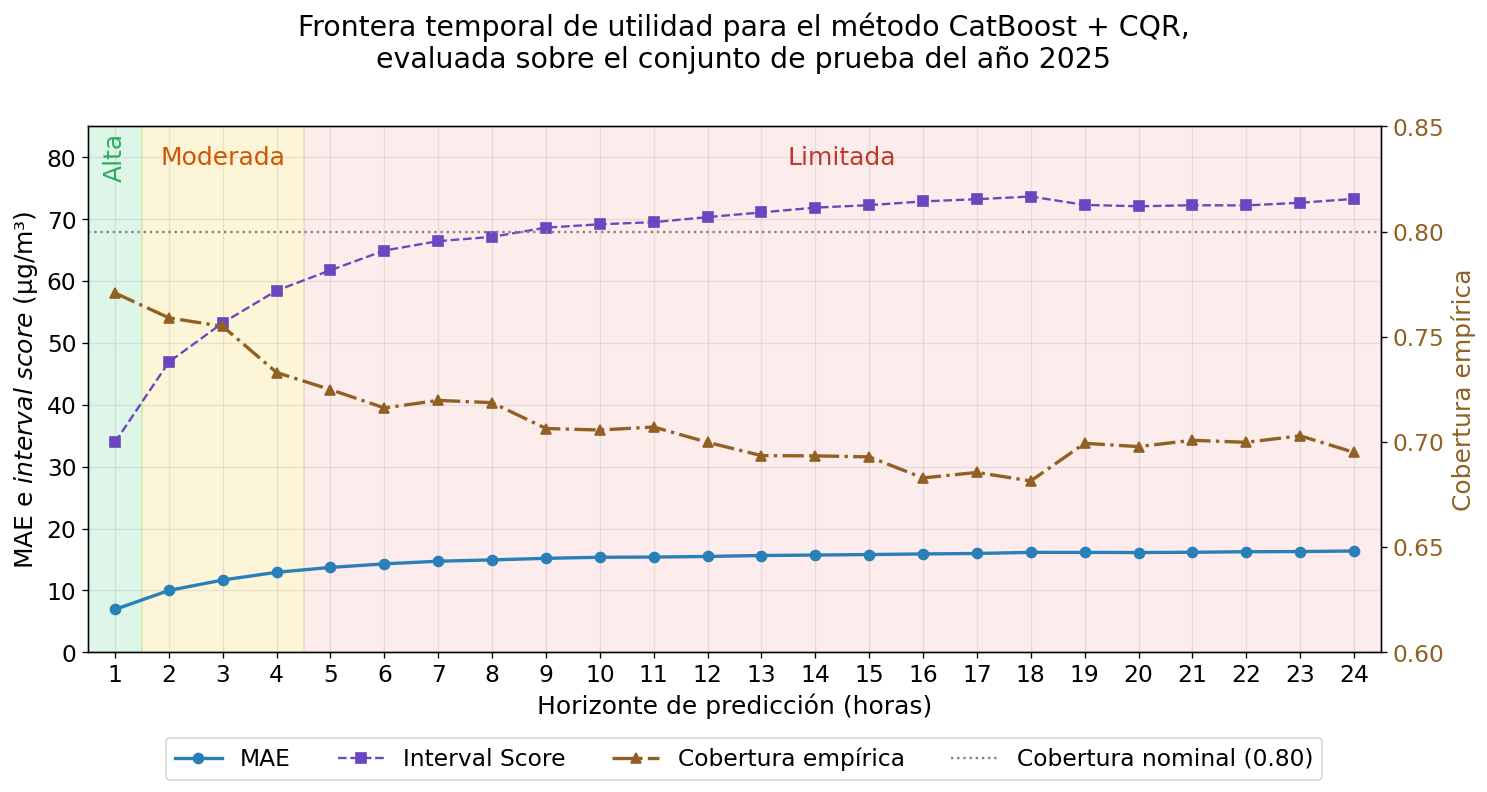

In [18]:
from matplotlib.lines import Line2D

if "frontier_df" in globals():
    plot_df = frontier_df.copy()
else:
    frontier_csv_path = REPORTS_TABLES_DIR / "frontier_decision_by_horizon.csv"
    if not frontier_csv_path.exists():
        frontier_csv_path = REPORTS_TABLES_DIR / "frontier_catboost_cqr_test_2025_all_horizons.csv"

    plot_df = pd.read_csv(frontier_csv_path)

plot_df = plot_df.sort_values("horizon").reset_index(drop=True)

required_columns = ["horizon", "mae", "mean_interval_score", "empirical_coverage"]
missing_columns = [col for col in required_columns if col not in plot_df.columns]
if missing_columns:
    raise ValueError(f"Faltan columnas necesarias para la figura: {missing_columns}")

horizontes = plot_df["horizon"].astype(int).to_numpy()
mae = plot_df["mae"].astype(float).to_numpy()
interval_score = plot_df["mean_interval_score"].astype(float).to_numpy()
cobertura = plot_df["empirical_coverage"].astype(float).to_numpy()

expected_horizons = set(range(1, 25))
available_horizons = set(horizontes)
if available_horizons != expected_horizons:
    print(f"Advertencia: la figura no contiene exactamente los horizontes 1-24. Horizontes disponibles: {sorted(available_horizons)}")

fig, ax1 = plt.subplots(figsize=(12.5, 6.5))

purple = "#6B46C1"
color_mae = "#2980b9"
color_cov = "#906123"
fill_alpha = 0.16

ax1.axvspan(0.5, 1.5, color="#2ecc71", alpha=fill_alpha)
ax1.axvspan(1.5, 4.5, color="#f1c40f", alpha=fill_alpha)
ax1.axvspan(4.5, 24.5, color="#e74c3c", alpha=0.1)

ax1.text(1, 80, "Alta", color="#27ae60", ha="center", va="center", fontsize=15, rotation=90)
ax1.text(3, 80, "Moderada", color="#d35400", ha="center", va="center", fontsize=15)
ax1.text(14.5, 80, "Limitada", color="#c0392b", ha="center", va="center", fontsize=15)

ax1.plot(horizontes, mae, marker="o", color=color_mae, linewidth=2.0)
ax1.plot(horizontes, interval_score, marker="s", linestyle="--",
         color=purple, linewidth=1.4)

ax1.set_xlabel("Horizonte de predicción (horas)", fontsize=15)
ax1.set_ylabel(r"MAE e $interval$ $score$ (µg/m³)", fontsize=15)
ax1.set_xlim(0.5, 24.5)
ax1.set_ylim(0, 85)
ax1.set_xticks(horizontes)
ax1.grid(True, alpha=0.28)
ax1.tick_params(axis="both", labelsize=14)

ax2 = ax1.twinx()
ax2.plot(horizontes, cobertura, marker="^", linestyle="-.",
         color=color_cov, linewidth=2.0)
ax2.axhline(0.80, color="gray", linestyle=":", linewidth=1.4)

ax2.set_ylabel("Cobertura empírica", color=color_cov, fontsize=15)
ax2.set_ylim(0.60, 0.85)
ax2.tick_params(axis="y", labelcolor=color_cov, labelsize=14)

legend_handles = [
    Line2D([0], [0], color=color_mae, marker="o", linewidth=2.0, label="MAE"),
    Line2D([0], [0], color=purple, marker="s", linestyle="--", linewidth=1.4, label="Interval Score"),
    Line2D([0], [0], color=color_cov, marker="^", linestyle="-.", linewidth=2.0, label="Cobertura empírica"),
    Line2D([0], [0], color="gray", linestyle=":", linewidth=1.4, label="Cobertura nominal (0.80)")
]

fig.suptitle(
    "Frontera temporal de utilidad para el método CatBoost + CQR,\n"
    "evaluada sobre el conjunto de prueba del año 2025",
    y=0.98,
    fontsize=17,
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=14,
)

fig.tight_layout(rect=(0, 0.05, 1, 0.97))

if "REPORTS_FIGURES_DIR" in globals():
    synthesis_figure_path = REPORTS_FIGURES_DIR / "temporal_threshold_catboost_cqr.png"

    if "save_figure" in globals():
        save_figure(fig, synthesis_figure_path)
    else:
        fig.savefig(synthesis_figure_path, dpi=200, bbox_inches="tight")

plt.show()

## Resumen de los resultados

Para finalizar, la siguiente celda genera un breve texto con los principales resultados obtenidos en el notebook.

In [19]:
strict_text = f"h = {strict_frontier}" if strict_frontier is not None else "sin frontera estricta contigua"
moderate_text = f"h = {moderate_frontier}" if moderate_frontier is not None else "sin frontera moderada contigua"

h1 = frontier_df.loc[frontier_df["horizon"] == 1].iloc[0]
h24 = frontier_df.loc[frontier_df["horizon"] == 24].iloc[0]

summary_text = (
    "Resumen de los resultados del notebook:\n"
    f"- En el conjunto de prueba (2025), CatBoost + CQR alcanzó en h=1 una cobertura de {h1['empirical_coverage']:.3f}, "
    f"con MAE={h1['mae']:.3f}, interval score={h1['mean_interval_score']:.3f} y F(h)={h1['F_h']:.3f}.\n"
    f"- En h=24, la cobertura fue de {h24['empirical_coverage']:.3f}, "
    f"con MAE={h24['mae']:.3f}, interval score={h24['mean_interval_score']:.3f} y F(h)={h24['F_h']:.3f}.\n"
    f"- La frontera estricta, definida por una cobertura >= {HIGH_COVERAGE_THRESHOLD:.2f} y un F(h) <= {HIGH_FRONTIER_SCORE_THRESHOLD:.2f}, queda en {strict_text}.\n"
    f"- La frontera moderada, definida por una cobertura >= {MODERATE_COVERAGE_THRESHOLD:.2f} y un F(h) <= {MODERATE_FRONTIER_SCORE_THRESHOLD:.2f}, queda en {moderate_text}."
)

print(summary_text)

summary_path = REPORTS_TABLES_DIR / "frontier_summary_text.txt"
summary_path.write_text(summary_text, encoding="utf-8")
SAVED_TABLE_PATHS.append(summary_path)
print(f"Resumen guardado: {summary_path}")


Resumen de los resultados del notebook:
- En el conjunto de prueba (2025), CatBoost + CQR alcanzó en h=1 una cobertura de 0.771, con MAE=6.916, interval score=33.947 y F(h)=0.000.
- En h=24, la cobertura fue de 0.695, con MAE=16.365, interval score=73.274 y F(h)=0.966.
- La frontera estricta, definida por una cobertura >= 0.75 y un F(h) <= 0.25, queda en h = 1.
- La frontera moderada, definida por una cobertura >= 0.70 y un F(h) <= 0.60, queda en h = 4.
Resumen guardado: c:\trabajo_github\reports\tables\frontier_summary_text.txt


## Comprobaciones finales

Se verifica que se hayan generado las tablas y figuras del notebook.


In [20]:
expected_outputs = [
    all_test_path,
    compact_test_path,
    comparison_path,
    compact_comparison_path,
    validation_test_figure_path,
    score_figure_path,
    miss_direction_path,
    miss_direction_figure_path,
    frontier_path,
    frontier_summary_path,
    test_metrics_figure_path,
    visual_intervals_figure_path,
    summary_path,
]

missing = [path for path in expected_outputs if not Path(path).exists()]
if missing:
    raise FileNotFoundError(f"No se han generado algunas salidas esperadas: {missing}")

final_outputs_df = pd.DataFrame(
    {
        "tipo": ["tabla" if path.suffix.lower() in {".csv", ".tex", ".txt"} else "figura" for path in expected_outputs],
        "ruta": [str(path.relative_to(PROJECT_ROOT)) for path in expected_outputs],
        "existe": [Path(path).exists() for path in expected_outputs],
    }
)

display(final_outputs_df)


,tipo,ruta,existe
0,tabla,reports\tables\frontier_catboost_cqr_test_2025...,True
1,tabla,reports\tables\frontier_catboost_cqr_test_2025...,True
2,tabla,reports\tables\frontier_validation_2024_vs_tes...,True
3,tabla,reports\tables\frontier_validation_2024_vs_tes...,True
4,figura,reports\figures\frontier_validation_2024_vs_te...,True
5,figura,reports\figures\frontier_test_2025_score_by_ho...,True
6,tabla,reports\tables\frontier_test_2025_miss_directi...,True
7,figura,reports\figures\frontier_test_2025_miss_direct...,True
8,tabla,reports\tables\frontier_decision_by_horizon.csv,True
9,tabla,reports\tables\frontier_summary.csv,True
